# BAF Variant Results Explorer

This notebook helps you explore benchmark results in an intuitive way:

1. Understand the **champion model architecture** end-to-end.
2. Inspect **overall benchmark outcomes** across all variants.
3. Drill into **each variant contextually** (what it challenges and why your scores look the way they do).
4. Get **actionable improvement ideas** for model performance and robustness.


In [1]:
from pathlib import Path
import json
import textwrap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "results" / "variants" / "aggregate_summary.json").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing results/variants/aggregate_summary.json")

repo_root = find_repo_root(Path.cwd())
summary_path = repo_root / "results" / "variants" / "aggregate_summary.json"
champion_path = repo_root / "results" / "variants" / "champion_model.json"

summary = json.loads(summary_path.read_text())
champion_manifest = json.loads(champion_path.read_text())

print(f"Loaded: {summary_path}")
print(f"Loaded: {champion_path}")

Loaded: C:\Users\admin\Desktop\user1\Fraud-Detection\results\variants\aggregate_summary.json
Loaded: C:\Users\admin\Desktop\user1\Fraud-Detection\results\variants\champion_model.json


In [2]:
rows = []
for item in summary["variants"]:
    row = {
        "variant": item["variant"],
        "data_path": item["data_path"],
        "winner": item["selection"]["preferred_model"],
        "delta_pr_auc": item["selection"]["delta_pr_auc_bootstrap"]["delta_mean"],
        "delta_pr_auc_ci_low": item["selection"]["delta_pr_auc_bootstrap"]["ci_low"],
        "delta_pr_auc_ci_high": item["selection"]["delta_pr_auc_bootstrap"]["ci_high"],
    }
    for model_name in ["vanilla", "enriched"]:
        m = item[model_name]
        row[f"{model_name}_pr_auc"] = m["pr_auc"]
        row[f"{model_name}_roc_auc"] = m["roc_auc"]
        row[f"{model_name}_f1"] = m["f1"]
        row[f"{model_name}_precision"] = m["precision"]
        row[f"{model_name}_recall"] = m["recall"]
        row[f"{model_name}_brier_calibrated"] = m["brier_calibrated"]
        row[f"{model_name}_alert_yield_pct"] = m["alert_yield_pct"]
        row[f"{model_name}_threshold"] = m["threshold"]
    rows.append(row)

variant_df = pd.DataFrame(rows).sort_values("variant").reset_index(drop=True)

display(Markdown("### Quick summary"))
display(pd.DataFrame({
    "variant_count": [summary["variant_count"]],
    "winner_vanilla": [summary["winner_counts"]["vanilla"]],
    "winner_enriched": [summary["winner_counts"]["enriched"]],
    "overall_champion": [summary["overall_champion"]],
}))

display(variant_df[[
    "variant", "winner", "vanilla_pr_auc", "enriched_pr_auc",
    "delta_pr_auc", "delta_pr_auc_ci_low", "delta_pr_auc_ci_high"
]])

### Quick summary

,variant_count,winner_vanilla,winner_enriched,overall_champion
0,6,1,5,enriched


,variant,winner,vanilla_pr_auc,enriched_pr_auc,delta_pr_auc,delta_pr_auc_ci_low,delta_pr_auc_ci_high
0,variant_base,enriched,0.191187,0.192435,0.001207,-0.002260,0.004642
1,variant_i,enriched,0.188136,0.195561,0.007350,0.003964,0.010481
2,variant_ii,enriched,0.193665,0.197671,0.003949,0.000678,0.007332
3,variant_iii,vanilla,0.503464,0.503330,-0.000125,-0.003382,0.002766
4,variant_iv,enriched,0.092997,0.097044,0.004098,0.001369,0.006905
5,variant_v,enriched,0.058315,0.059814,0.001488,-0.000059,0.003110


## 1) Champion Architecture (Overall)

This section explains how the selected champion (`enriched`) works from raw data to deployment.

- **Input**: Variant-specific BAF tabular dataset.
- **Time split protocol**: train months `0-5`, valid `6`, test `7`.
- **Base feature preprocessing**: median imputation + optional Yeo-Johnson + scaling.
- **Retriever enrichment**: additional context-derived features are concatenated.
- **Modeling**: XGBoost classifier + optional SMOTE on train split.
- **Calibration**: Platt scaling learned on validation predictions.
- **Selection logic**: compare vanilla vs enriched per variant, then choose overall champion by winner count.
- **Inference**: champion model + calibrator + report generation.


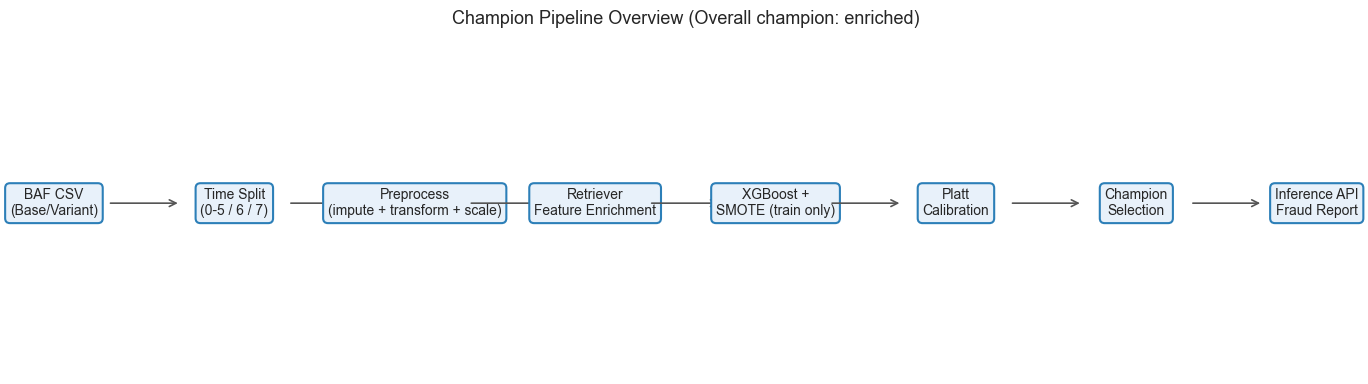

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

steps = [
    "BAF CSV\n(Base/Variant)",
    "Time Split\n(0-5 / 6 / 7)",
    "Preprocess\n(impute + transform + scale)",
    "Retriever\nFeature Enrichment",
    "XGBoost +\nSMOTE (train only)",
    "Platt\nCalibration",
    "Champion\nSelection",
    "Inference API\nFraud Report"
]

x_positions = np.linspace(0.03, 0.97, len(steps))
for i, (x, label) in enumerate(zip(x_positions, steps)):
    ax.text(
        x, 0.5, label,
        ha="center", va="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", fc="#E8F1FA", ec="#2C7FB8", lw=1.5),
        transform=ax.transAxes,
    )
    if i < len(steps) - 1:
        ax.annotate(
            "", xy=(x_positions[i + 1] - 0.04, 0.5), xytext=(x + 0.04, 0.5),
            xycoords=ax.transAxes, textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#555555"),
        )

ax.set_title(f"Champion Pipeline Overview (Overall champion: {champion_manifest['overall_champion']})", fontsize=13)
plt.tight_layout()
plt.show()

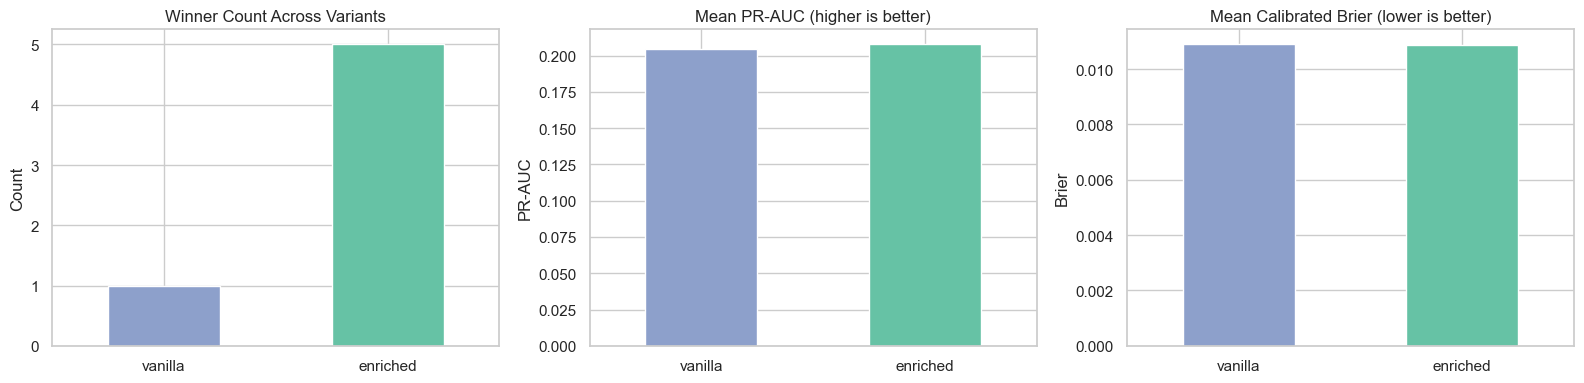

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Winner counts
winner_counts = pd.Series(summary["winner_counts"])
winner_counts.plot(kind="bar", ax=axes[0], color=["#8DA0CB", "#66C2A5"])
axes[0].set_title("Winner Count Across Variants")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Mean PR-AUC
mean_pr = pd.Series({
    "vanilla": summary["metrics_aggregate"]["vanilla_pr_auc"]["mean"],
    "enriched": summary["metrics_aggregate"]["enriched_pr_auc"]["mean"],
})
mean_pr.plot(kind="bar", ax=axes[1], color=["#8DA0CB", "#66C2A5"])
axes[1].set_title("Mean PR-AUC (higher is better)")
axes[1].set_ylabel("PR-AUC")
axes[1].tick_params(axis="x", rotation=0)

# Mean calibrated Brier
mean_brier = pd.Series({
    "vanilla": summary["metrics_aggregate"]["vanilla_brier_calibrated"]["mean"],
    "enriched": summary["metrics_aggregate"]["enriched_brier_calibrated"]["mean"],
})
mean_brier.plot(kind="bar", ax=axes[2], color=["#8DA0CB", "#66C2A5"])
axes[2].set_title("Mean Calibrated Brier (lower is better)")
axes[2].set_ylabel("Brier")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 2) Variant Context + Results Meaning

Variant definitions used below:

- **Base**: representative sample of original dataset.
- **Variant I**: higher group size disparity.
- **Variant II**: higher prevalence disparity.
- **Variant III**: better separability for one group.
- **Variant IV**: higher prevalence disparity in train.
- **Variant V**: better separability in train for one group.

These contexts matter because they stress different failure modes: class imbalance, distribution shift, subgroup asymmetry, and train-test mismatch.


In [5]:
variant_context = {
    "variant_base": {
        "display_name": "Base",
        "challenge": "Representative baseline",
    },
    "variant_i": {
        "display_name": "Variant I",
        "challenge": "Higher group size disparity",
    },
    "variant_ii": {
        "display_name": "Variant II",
        "challenge": "Higher prevalence disparity",
    },
    "variant_iii": {
        "display_name": "Variant III",
        "challenge": "Better separability for one group",
    },
    "variant_iv": {
        "display_name": "Variant IV",
        "challenge": "Higher prevalence disparity in train",
    },
    "variant_v": {
        "display_name": "Variant V",
        "challenge": "Better separability in train for one group",
    },
}

variant_df["variant_label"] = variant_df["variant"].map(lambda x: variant_context[x]["display_name"])
variant_df["challenge"] = variant_df["variant"].map(lambda x: variant_context[x]["challenge"])

display(variant_df[[
    "variant_label", "challenge", "winner",
    "vanilla_pr_auc", "enriched_pr_auc", "delta_pr_auc",
    "vanilla_precision", "enriched_precision",
    "vanilla_recall", "enriched_recall",
]].sort_values("variant_label"))

,variant_label,challenge,winner,vanilla_pr_auc,enriched_pr_auc,delta_pr_auc,vanilla_precision,enriched_precision,vanilla_recall,enriched_recall
0,Base,Representative baseline,enriched,0.191187,0.192435,0.001207,0.206275,0.246914,0.368347,0.280112
1,Variant I,Higher group size disparity,enriched,0.188136,0.195561,0.007350,0.226987,0.246879,0.278011,0.249300
2,Variant II,Higher prevalence disparity,enriched,0.193665,0.197671,0.003949,0.269737,0.244863,0.258403,0.300420
3,Variant III,Better separability for one group,vanilla,0.503464,0.503330,-0.000125,0.595683,0.621212,0.420732,0.416667
4,Variant IV,Higher prevalence disparity in train,enriched,0.092997,0.097044,0.004098,0.120102,0.130508,0.239837,0.237805
5,Variant V,Better separability in train for one group,enriched,0.058315,0.059814,0.001488,0.094209,0.097028,0.234756,0.225610


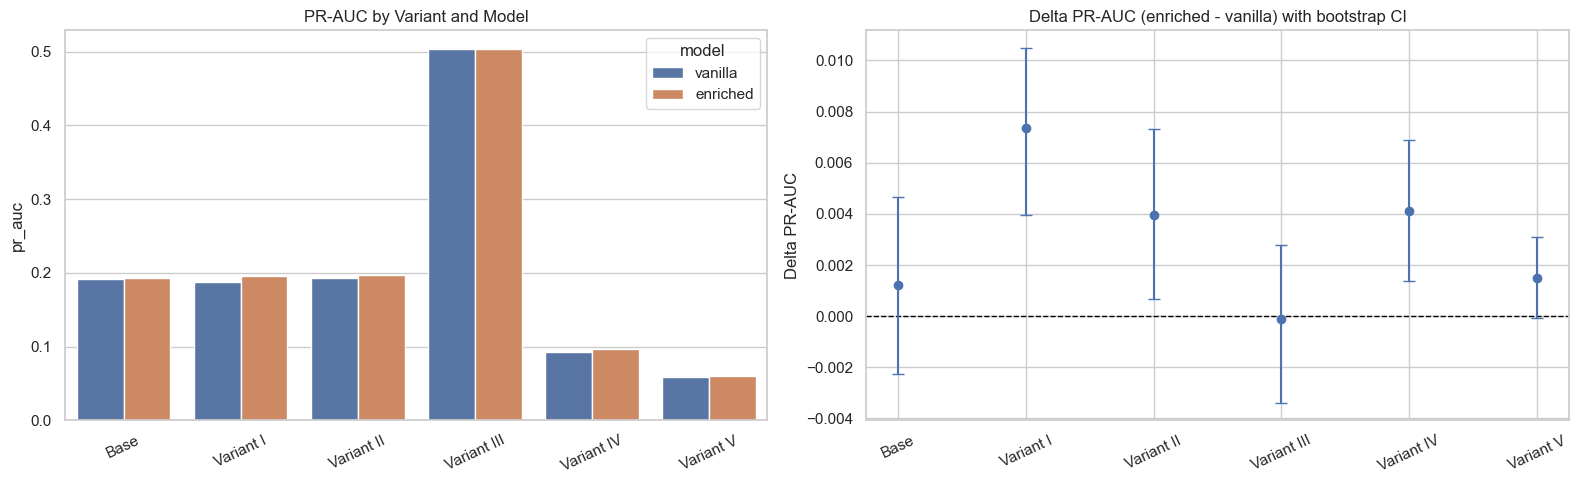

In [6]:
plot_df = variant_df[["variant_label", "vanilla_pr_auc", "enriched_pr_auc"]].melt(
    id_vars="variant_label", var_name="model", value_name="pr_auc"
)
plot_df["model"] = plot_df["model"].str.replace("_pr_auc", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=plot_df, x="variant_label", y="pr_auc", hue="model", ax=axes[0])
axes[0].set_title("PR-AUC by Variant and Model")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

delta_df = variant_df[["variant_label", "delta_pr_auc", "delta_pr_auc_ci_low", "delta_pr_auc_ci_high"]].copy()
axes[1].axhline(0.0, color="black", lw=1, linestyle="--")
axes[1].errorbar(
    x=np.arange(len(delta_df)),
    y=delta_df["delta_pr_auc"],
    yerr=[
        delta_df["delta_pr_auc"] - delta_df["delta_pr_auc_ci_low"],
        delta_df["delta_pr_auc_ci_high"] - delta_df["delta_pr_auc"],
    ],
    fmt="o", capsize=4,
)
axes[1].set_xticks(np.arange(len(delta_df)))
axes[1].set_xticklabels(delta_df["variant_label"], rotation=25)
axes[1].set_title("Delta PR-AUC (enriched - vanilla) with bootstrap CI")
axes[1].set_ylabel("Delta PR-AUC")

plt.tight_layout()
plt.show()

In [7]:
def improvement_suggestions(row: pd.Series) -> list[str]:
    suggestions = []

    if row["enriched_pr_auc"] < 0.10:
        suggestions.append("Low PR-AUC: tune class-imbalance strategy (SMOTE ratio, class weights, focal-style objective) and optimize threshold for business cost.")
    elif row["enriched_pr_auc"] < 0.20:
        suggestions.append("Moderate PR-AUC: expand discriminative features (temporal, velocity, cross-feature interactions) and run deeper hyperparameter search.")
    else:
        suggestions.append("Strong separability: preserve precision-recall tradeoff with calibrated threshold selection by operating point (manual review capacity).")

    if row["enriched_recall"] < 0.20:
        suggestions.append("Recall is low: lower decision threshold, test recall-oriented objective, and evaluate top-k recall for alert queues.")

    if row["enriched_precision"] < 0.15:
        suggestions.append("Precision is low: add hard-negative mining and post-model business rules to reduce false positives.")

    ci_low, ci_high = row["delta_pr_auc_ci_low"], row["delta_pr_auc_ci_high"]
    if ci_low <= 0 <= ci_high:
        suggestions.append("Model advantage is not statistically decisive on this variant; treat vanilla/enriched as comparable and verify on additional slices.")

    return suggestions

def contextual_meaning(row: pd.Series) -> str:
    challenge = row["challenge"]
    winner = row["winner"]
    d = row["delta_pr_auc"]

    core = (
        f"This variant stresses **{challenge.lower()}**. "
        f"The current winner is **{winner}** with delta PR-AUC = **{d:.4f}** (enriched - vanilla)."
    )

    if d > 0.003:
        return core + " The enriched pipeline is meaningfully helping under this shift."
    if d > 0:
        return core + " The enriched pipeline helps, but only marginally."
    return core + " Vanilla remains competitive or better here; enrichment may need retuning for this data regime."

for _, row in variant_df.sort_values("variant_label").iterrows():
    display(Markdown(f"### {row['variant_label']}"))
    display(Markdown(contextual_meaning(row)))

    metrics_table = pd.DataFrame({
        "metric": ["PR-AUC", "ROC-AUC", "Precision", "Recall", "F1", "Calibrated Brier", "Alert Yield %", "Threshold"],
        "vanilla": [
            row["vanilla_pr_auc"], row["vanilla_roc_auc"], row["vanilla_precision"], row["vanilla_recall"],
            row["vanilla_f1"], row["vanilla_brier_calibrated"], row["vanilla_alert_yield_pct"], row["vanilla_threshold"]
        ],
        "enriched": [
            row["enriched_pr_auc"], row["enriched_roc_auc"], row["enriched_precision"], row["enriched_recall"],
            row["enriched_f1"], row["enriched_brier_calibrated"], row["enriched_alert_yield_pct"], row["enriched_threshold"]
        ],
    })
    display(metrics_table)

    suggestions = improvement_suggestions(row)
    suggestions_md = "\n".join([f"- {s}" for s in suggestions])
    display(Markdown("**How to improve performance here**\n" + suggestions_md))
    display(Markdown("---"))

### Base

This variant stresses **representative baseline**. The current winner is **enriched** with delta PR-AUC = **0.0012** (enriched - vanilla). The enriched pipeline helps, but only marginally.

,metric,vanilla,enriched
0,PR-AUC,0.191187,0.192435
1,ROC-AUC,0.887152,0.886582
2,Precision,0.206275,0.246914
3,Recall,0.368347,0.280112
4,F1,0.264454,0.262467
5,Calibrated Brier,0.013590,0.013603
6,Alert Yield %,2.633128,1.672811
7,Threshold,0.150000,0.200000


**How to improve performance here**
- Moderate PR-AUC: expand discriminative features (temporal, velocity, cross-feature interactions) and run deeper hyperparameter search.
- Model advantage is not statistically decisive on this variant; treat vanilla/enriched as comparable and verify on additional slices.

---

...

### Variant V

This variant stresses **better separability in train for one group**. The current winner is **enriched** with delta PR-AUC = **0.0015** (enriched - vanilla). The enriched pipeline helps, but only marginally.

,metric,vanilla,enriched
0,PR-AUC,0.058315,0.059814
1,ROC-AUC,0.799041,0.802793
2,Precision,0.094209,0.097028
3,Recall,0.234756,0.225610
4,F1,0.134459,0.135697
5,Calibrated Brier,0.009267,0.009288
6,Alert Yield %,2.322410,2.167077
7,Threshold,0.100000,0.100000


**How to improve performance here**
- Low PR-AUC: tune class-imbalance strategy (SMOTE ratio, class weights, focal-style objective) and optimize threshold for business cost.
- Precision is low: add hard-negative mining and post-model business rules to reduce false positives.
- Model advantage is not statistically decisive on this variant; treat vanilla/enriched as comparable and verify on additional slices.

---

## 3) Recommended Next Experiments

Use these high-impact follow-ups to improve both performance and robustness:

1. **Variant-specific threshold tuning** under business constraints (fixed review capacity).
2. **Targeted hyperparameter sweeps** for hard variants (IV, V in your run).
3. **Ablation of retriever features** to identify strongest contributors.
4. **Fairness-aware evaluation** by passing subgroup columns and tracking parity/equal-opportunity deltas.
5. **Confidence/stability checks**: rerun with seeds and compare distribution of delta PR-AUC.

You can duplicate this notebook and add experiment logs per run to build a lightweight model card over time.
